# Experiment No. – 3

## Aim
To understand the bias-variance tradeoff by fitting polynomial regression models of varying degrees.

## Dataset
UCI Energy Efficiency Dataset

## Objective
To investigate the bias-variance tradeoff by fitting polynomial regression models of degrees 1 to 10 and comparing their training and testing RMSE.

Import the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Load the UCI Energy Efficiency Dataset

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"

data = pd.read_excel(url)

data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [3]:
data.shape

(768, 10)

In [4]:
data.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [6]:
data.isnull().sum()

X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

- X1 -> Relative Compactness
- X2 -> Surface Area
- X3 -> Wall Area
- X4 -> Roof Area
- X5 -> Overall Height
- X6 -> Orientation
- X7 -> Glazing Area
- X8 -> Glazing Area Distribution

- Y1 -> Heating Load
- Y2 -> Cooling Load

In [8]:
x = data.iloc[:,0:8]
y = data["Y1"]

In [9]:
print("X shape: ", x.shape)
print("Y shape: ", y.shape)

X shape:  (768, 8)
Y shape:  (768,)


In [10]:
y.head()

0    15.55
1    15.55
2    15.55
3    15.55
4    20.84
Name: Y1, dtype: float64

In [11]:
y.describe()

count    768.000000
mean      22.307195
std       10.090204
min        6.010000
25%       12.992500
50%       18.950000
75%       31.667500
max       43.100000
Name: Y1, dtype: float64

Split the dataset

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
print("Training data: ", x_train.shape)
print("Testing data: ", x_test.shape)

Training data:  (614, 8)
Testing data:  (154, 8)


Standardize the features

In [14]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [15]:
scaler.fit_transform(x_train)

array([[ 0.55367107, -0.6962224 , -0.00737214, ..., -1.36441084,
        -1.01029954, -1.1605984 ],
       [-1.15511771,  1.25066366,  0.55843925, ...,  0.44108109,
         1.22779036, -0.51570481],
       [ 0.93340191, -0.97434898, -0.57318352, ...,  0.44108109,
         0.10874541, -0.51570481],
       ...,
       [-0.49058874,  0.41628392, -1.13899491, ...,  0.44108109,
        -1.01029954,  1.41897596],
       [ 2.07259443, -1.80872872, -0.57318352, ...,  1.34382706,
         0.10874541,  0.77408237],
       [ 1.31313275, -1.25247556, -0.00737214, ...,  0.44108109,
        -1.01029954, -0.51570481]], shape=(614, 8))

In [16]:
scaler.fit_transform(x_test)

array([[-1.44553277,  1.66427207,  1.12362347, ..., -1.25707872,
         1.31264168,  0.08819715],
       [-1.07029123,  1.10283089,  0.02844616, ..., -1.25707872,
         0.1530997 , -1.20536112],
       [ 1.93164114, -1.70437501, -0.51914249, ..., -1.25707872,
         1.31264168,  0.08819715],
       ...,
       [ 0.8059165 , -0.86221324, -0.51914249, ..., -1.25707872,
         0.1530997 , -0.55858198],
       [ 0.8059165 , -0.86221324, -0.51914249, ..., -1.25707872,
         0.1530997 , -1.20536112],
       [-0.60123929,  0.54138971, -1.06673115, ...,  0.47140452,
         0.1530997 ,  0.73497629]], shape=(154, 8))

In [17]:
degrees = []
train_rmse = []
test_rmse = []

Train Polynomial Regression models

In [18]:
for degree in range(1, 11):
    poly = PolynomialFeatures(degree=degree)
    
    x_train_poly = poly.fit_transform(x_train_scaled)
    x_test_poly = poly.transform(x_test_scaled)
    
    model = LinearRegression()
    model.fit(x_train_poly, y_train)
    
    # Predictions
    y_train_pred = model.predict(x_train_poly)
    y_test_pred = model.predict(x_test_poly)
    
    ## Calculate RMSE
    train_error = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_error = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Store results
    degrees.append(degree)
    train_rmse.append(train_error)
    test_rmse.append(test_error)
    

Display the results

In [19]:
results = pd.DataFrame({
    "Polynomial Degree": degrees,
    "Training RMSE": train_rmse,
    "Testing RMSE": test_rmse
})

results

,Polynomial Degree,Training RMSE,Testing RMSE
0,1,2.893119e+00,3.025427
1,2,6.977417e-01,0.802953
2,3,4.043118e-01,0.541739
3,4,3.084757e-01,0.453254
4,5,2.157103e-01,0.488982
5,6,1.399700e-01,0.962452
6,7,3.843512e-02,20.006646
7,8,3.514294e-13,7.893374
8,9,1.523735e-12,6.166598
9,10,3.636678e-12,8.386179


In [20]:
best_degree = results.loc[
    results["Testing RMSE"].idxmin(),
    "Polynomial Degree"
]

best_test_rmse = results["Testing RMSE"].min()

print("Best Polynomial Degree:", best_degree)
print("Lowest Testing RMSE:", best_test_rmse)

Best Polynomial Degree: 4
Lowest Testing RMSE: 0.45325392214774296


Plot Training and Testing RMSE

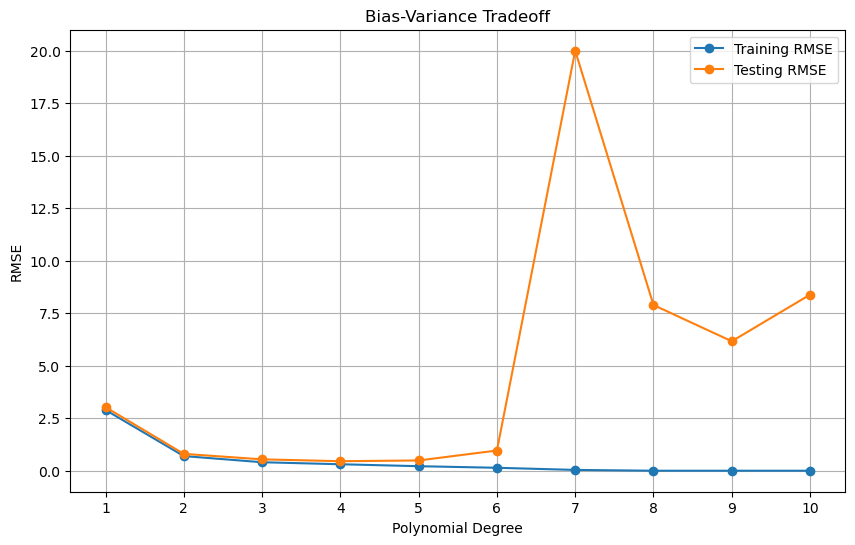

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    degrees,
    train_rmse,
    marker='o',
    label='Training RMSE'
)

plt.plot(
    degrees,
    test_rmse,
    marker='o',
    label='Testing RMSE'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Bias-Variance Tradeoff")
plt.xticks(degrees)
plt.legend()
plt.grid(True)

plt.show()

Compare training and testing error

In [22]:
for i in range(len(degrees)):
    print(
        "Degree:", degrees[i],
        "| Training RMSE:", round(train_rmse[i], 4),
        "| Testing RMSE:", round(test_rmse[i], 4)
    )

Degree: 1 | Training RMSE: 2.8931 | Testing RMSE: 3.0254
Degree: 2 | Training RMSE: 0.6977 | Testing RMSE: 0.803
Degree: 3 | Training RMSE: 0.4043 | Testing RMSE: 0.5417
Degree: 4 | Training RMSE: 0.3085 | Testing RMSE: 0.4533
Degree: 5 | Training RMSE: 0.2157 | Testing RMSE: 0.489
Degree: 6 | Training RMSE: 0.14 | Testing RMSE: 0.9625
Degree: 7 | Training RMSE: 0.0384 | Testing RMSE: 20.0066
Degree: 8 | Training RMSE: 0.0 | Testing RMSE: 7.8934
Degree: 9 | Training RMSE: 0.0 | Testing RMSE: 6.1666
Degree: 10 | Training RMSE: 0.0 | Testing RMSE: 8.3862


Visualize the target distribution

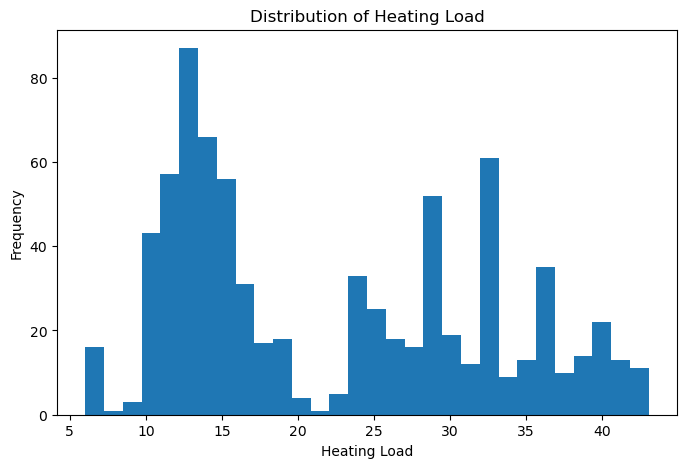

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(y, bins=30)

plt.xlabel("Heating Load")
plt.ylabel("Frequency")
plt.title("Distribution of Heating Load")

plt.show()

Correlation visualization

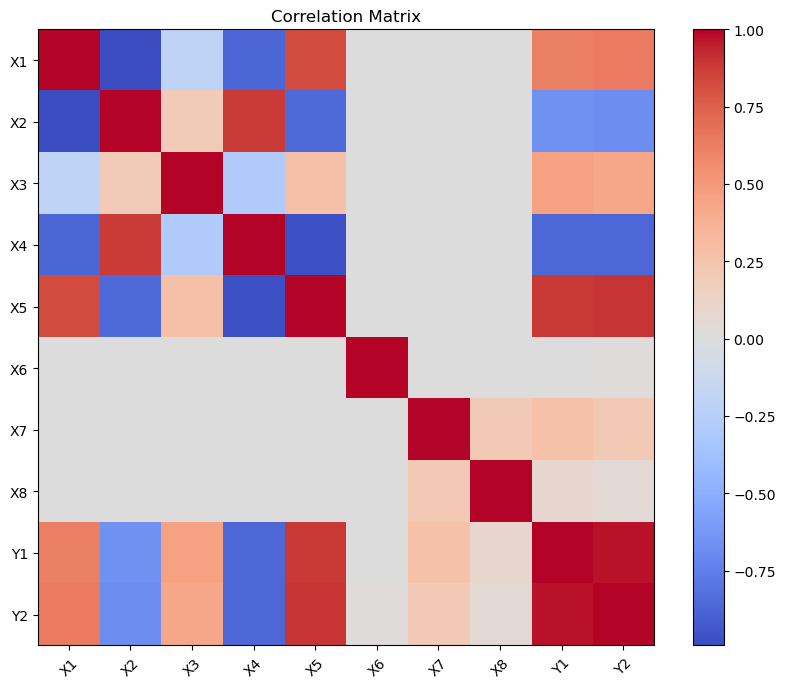

In [24]:
plt.figure(figsize=(10, 8))

plt.imshow(data.corr(), cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(data.columns)), data.columns, rotation=45)
plt.yticks(range(len(data.columns)), data.columns)

plt.title("Correlation Matrix")

plt.show()

## Conclusion

Polynomial Regression models of degrees 1 to 10 were implemented on the UCI Energy Efficiency dataset to study the bias-variance tradeoff.

The training and testing RMSE values were calculated for each polynomial degree. As the polynomial degree increased, the model became more complex and the training error generally decreased. However, after a certain degree, the testing error may increase, indicating overfitting and high variance.

A very low polynomial degree may result in underfitting because the model is too simple to capture the underlying relationship in the data. The polynomial degree with the lowest testing RMSE provides a better balance between bias and variance and generally gives better generalization performance.

Thus, the experiment demonstrates that selecting an appropriate model complexity is important for achieving good performance on unseen data.